# Лабораторна робота №6: Використання самоорганізуючихся карт Кохонена (SOM)
**Дисципліна:** Інтелектуальний аналіз даних  
**Студент:** Багрій-Белз Андрій, група КН-2327Б  
**Мета:** Дослідити архітектуру і практичне застосування самоорганізуючихся карт Кохонена (SOM) для задач неконтрольованої кластеризації, проєкції багатовимірних просторів на двовимірну решітку, аналізу міжнейронних відстаней та компонентних карт.

### Крок 1. Встановлення та імпорт бібліотек
Підготовка середовища (підтримка Google Colab та локального запуску).

In [1]:
!pip install minisom -q

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from minisom import MiniSom

os.makedirs('figures', exist_ok=True)
print("Бібліотеки успішно завантажено.")

Бібліотеки успішно завантажено.

### Крок 2. Завантаження набору даних Boston Housing
Відбираємо 7 репрезентативних числових ознак: INDUS, DIS, NOX, LSTAT, AGE, RAD, B.

In [2]:
boston = fetch_openml(name='boston', version=2, as_frame=True)
df = boston.frame
var_names = ['INDUS', 'DIS', 'NOX', 'LSTAT', 'AGE', 'RAD', 'B']
data = df[var_names].astype(float)

print(f"Розмірність вибірки: {data.shape[0]} спостережень, {data.shape[1]} ознак.")
print(data.head())

Розмірність вибірки: 506 спостережень, 7 ознак.
   INDUS     DIS    NOX  LSTAT   AGE  RAD       B
0   2.31  4.0900  0.538   4.98  65.2  1.0  396.90
1   7.07  4.9671  0.469   9.14  78.9  2.0  396.90
2   7.07  4.9671  0.469   4.03  61.1  2.0  392.83
3   2.18  6.0622  0.458   2.94  45.8  3.0  394.63
4   2.18  6.0622  0.458   5.33  54.2  3.0  396.90

### Крок 3. Стандартизація вхідних ознак
Оскільки SOM використовує евклідову відстань у просторі ознак, стандартизуємо дані за допомогою StandardScaler.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)
print("Форма стандартизованої матриці:", X_scaled.shape)
print("Середнє:", np.mean(X_scaled, axis=0).round(4))
print("Дисперсія:", np.var(X_scaled, axis=0).round(4))

Форма стандартизованої матриці: (506, 7)
Середнє: [ 0. -0. -0. -0. -0. -0. -0.]
Дисперсія: [1. 1. 1. 1. 1. 1. 1.]

### Крок 4. Ініціалізація та навчання решітки SOM
Задаємо сітку 9 x 6 (54 нейрони), sigma=1.0, learning_rate=0.5 та 100 ітерацій пакетного навчання.

In [4]:
grid_x, grid_y = 9, 6
som = MiniSom(grid_x, grid_y, X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)

num_iterations = 100
errors = []
for i in range(num_iterations):
    som.train_batch(X_scaled, num_iteration=1, verbose=False)
    errors.append(som.quantization_error(X_scaled))

final_qe = errors[-1]
topo_error = som.topographic_error(X_scaled)
print(f"Початкова Quantization Error: {errors[0]:.4f}")
print(f"Фінальна Quantization Error: {final_qe:.4f}")
print(f"Топографічна похибка (Topographic Error): {topo_error:.4f}")

Початкова Quantization Error: 1.8212
Фінальна Quantization Error: 1.7809
Топографічна похибка (Topographic Error): 0.7134

### Крок 5. Динаміка похибки квантування
Фіксація збіжності середньої евклідової відстані від спостережень до їхніх BMU.

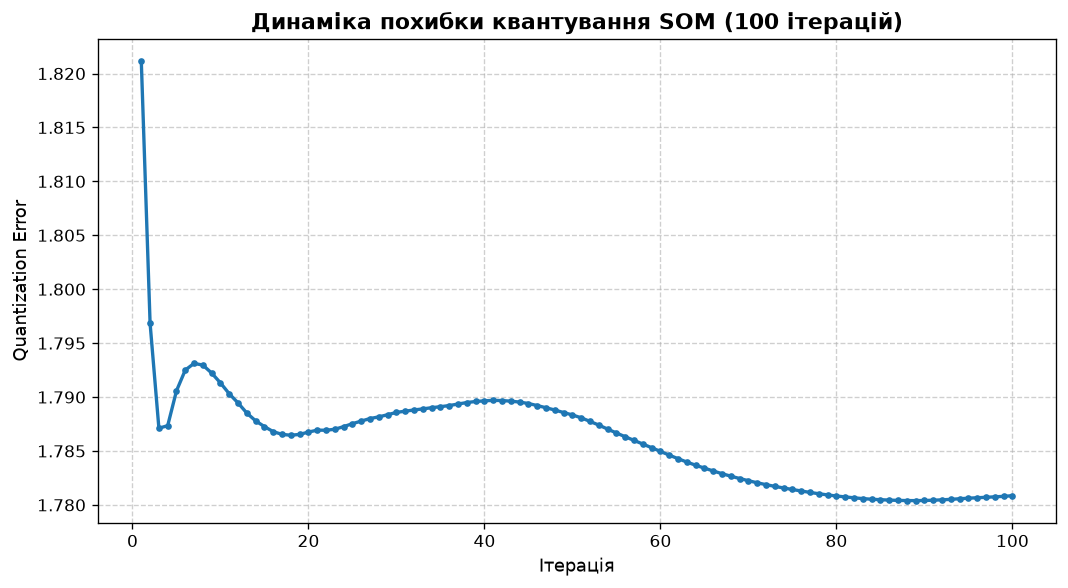

In [5]:
plt.figure(figsize=(9, 5), dpi=120)
plt.plot(range(1, num_iterations + 1), errors, marker='o', markersize=3, color='#1f77b4', lw=2)
plt.title('Динаміка похибки квантування SOM (100 ітерацій)', fontsize=13, fontweight='bold')
plt.xlabel('Ітерація', fontsize=11)
plt.ylabel('Quantization Error', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('figures/som_training_loss.png')
plt.show()

### Крок 6. Побудова U-Matrix (карта міжнейронних відстаней)
Аналіз топологічної структури латентного простору: світлі комірки — щільні кластери, темні бар'єри — межі між кластерами.

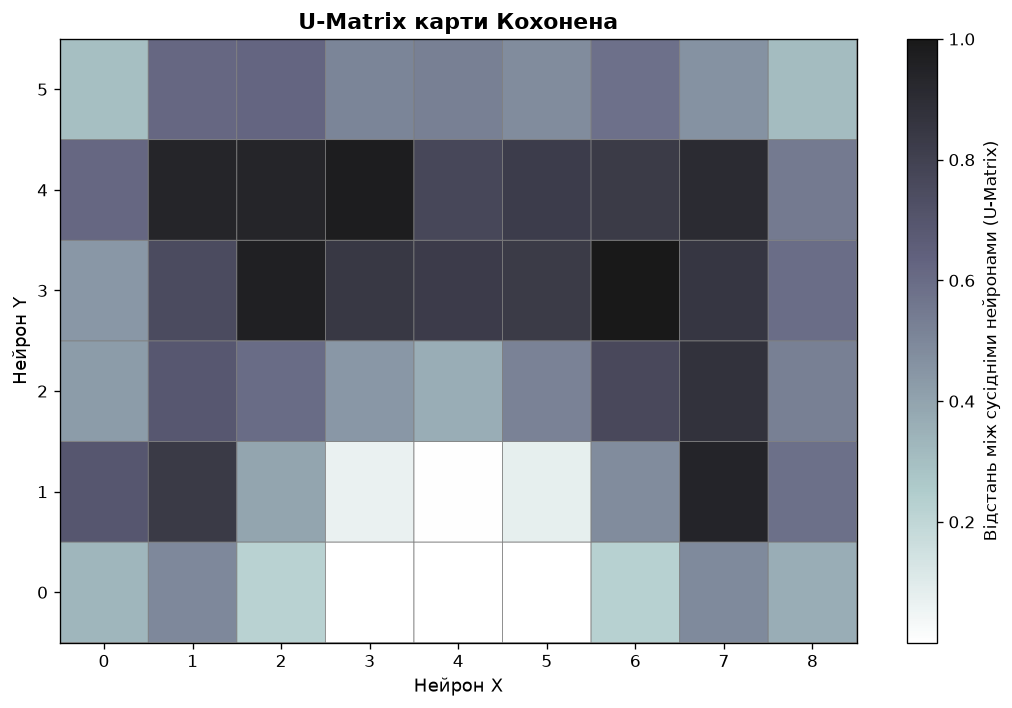

In [6]:
umatrix = som.distance_map().T
plt.figure(figsize=(9, 6), dpi=120)
plt.pcolor(umatrix, cmap='bone_r', alpha=0.9, edgecolors='gray', linewidths=0.5)
plt.colorbar(label='Відстань між сусідніми нейронами (U-Matrix)')
plt.title('U-Matrix карти Кохонена', fontsize=13, fontweight='bold')
plt.xlabel('Нейрон X', fontsize=11)
plt.ylabel('Нейрон Y', fontsize=11)
plt.xticks(np.arange(grid_x) + 0.5, range(grid_x))
plt.yticks(np.arange(grid_y) + 0.5, range(grid_y))
plt.tight_layout()
plt.savefig('figures/som_umatrix.png')
plt.show()

### Крок 7. Матриця активацій (частота потраплянь у нейрони)
Оцінка рівномірності заповнення простору об'єктами вибірки та виявлення ядер згущення.

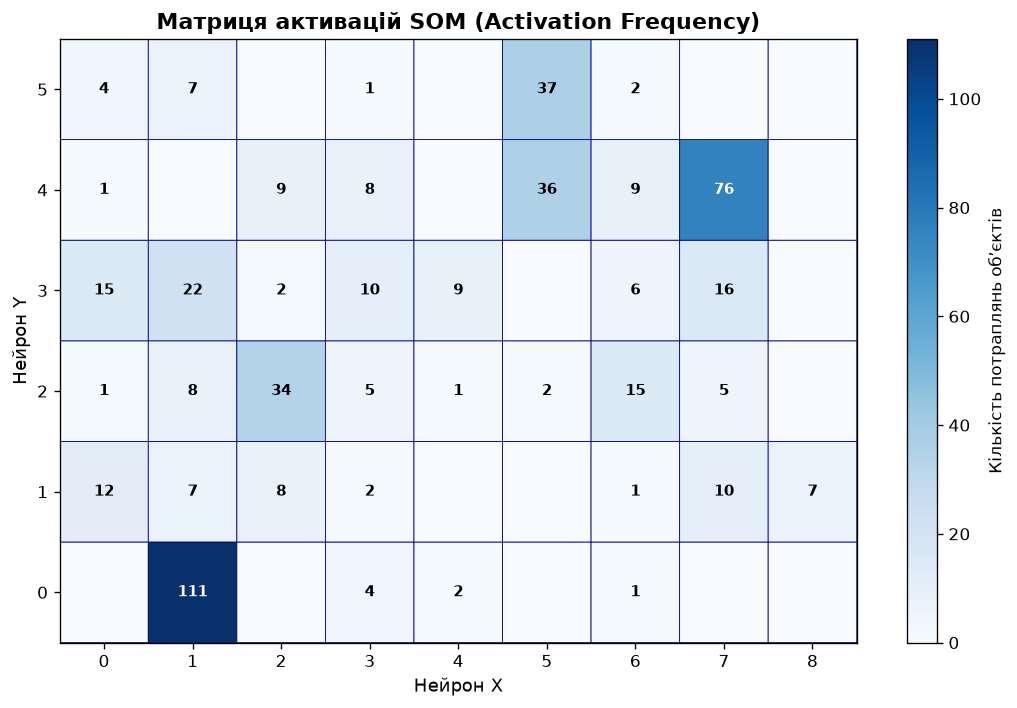

In [7]:
counts = som.activation_response(X_scaled).T
plt.figure(figsize=(9, 6), dpi=120)
plt.pcolor(counts, cmap='Blues', edgecolors='navy', linewidths=0.5)
plt.colorbar(label='Кількість потраплянь об’єктів')
plt.title('Матриця активацій SOM (Activation Frequency)', fontsize=13, fontweight='bold')
plt.xlabel('Нейрон X', fontsize=11)
plt.ylabel('Нейрон Y', fontsize=11)
plt.xticks(np.arange(grid_x) + 0.5, range(grid_x))
plt.yticks(np.arange(grid_y) + 0.5, range(grid_y))

for ix in range(grid_x):
    for iy in range(grid_y):
        val = int(counts[iy, ix])
        if val > 0:
            plt.text(ix + 0.5, iy + 0.5, str(val), ha='center', va='center',
                     fontsize=9, color='white' if val > counts.max() * 0.6 else 'black', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/som_counts.png')
plt.show()

### Крок 8. Проєкція об'єктів (BMU) за рівнем LSTAT
Пошук нейронів-переможців для спостережень та їх візуалізація поверх U-Matrix з колірним кодуванням за часткою малозабезпеченого населення.

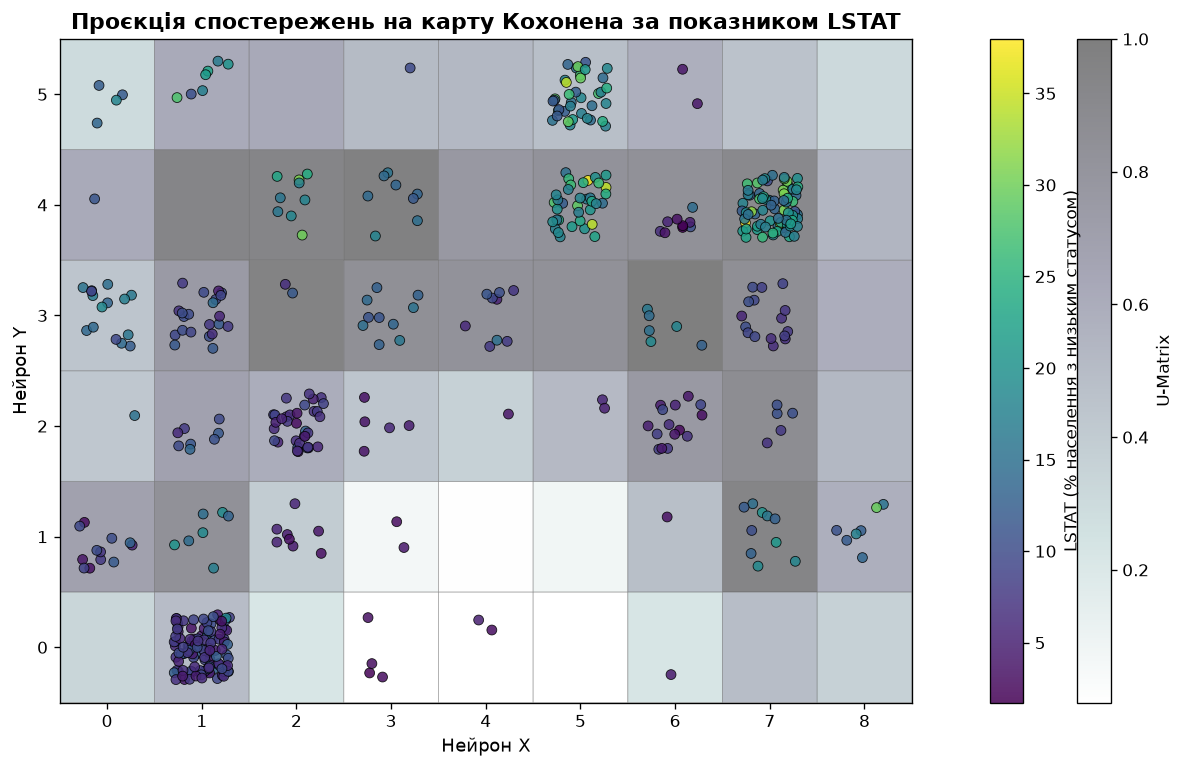

In [8]:
bmu_coords = np.array([som.winner(x) for x in X_scaled])
np.random.seed(42)
jitter_x = (np.random.rand(len(bmu_coords)) - 0.5) * 0.6
jitter_y = (np.random.rand(len(bmu_coords)) - 0.5) * 0.6

plt.figure(figsize=(10, 6.5), dpi=120)
plt.pcolor(umatrix, cmap='bone_r', alpha=0.5, edgecolors='gray', linewidths=0.5)
plt.colorbar(label='U-Matrix', fraction=0.046, pad=0.04)

scatter = plt.scatter(bmu_coords[:, 0] + 0.5 + jitter_x,
                      bmu_coords[:, 1] + 0.5 + jitter_y,
                      c=df['LSTAT'], cmap='viridis', s=35, edgecolors='k', linewidth=0.5, alpha=0.85)
plt.colorbar(scatter, label='LSTAT (% населення з низьким статусом)', fraction=0.046, pad=0.08)

plt.title('Проєкція спостережень на карту Кохонена за показником LSTAT', fontsize=13, fontweight='bold')
plt.xlabel('Нейрон X', fontsize=11)
plt.ylabel('Нейрон Y', fontsize=11)
plt.xticks(np.arange(grid_x) + 0.5, range(grid_x))
plt.yticks(np.arange(grid_y) + 0.5, range(grid_y))
plt.tight_layout()
plt.savefig('figures/som_bmu_mapping.png')
plt.show()

### Крок 9. Компонентні площини (Component Planes)
Візуалізація вагових коефіцієнтів решітки для кожної змінної з метою виявлення прихованих кореляцій.

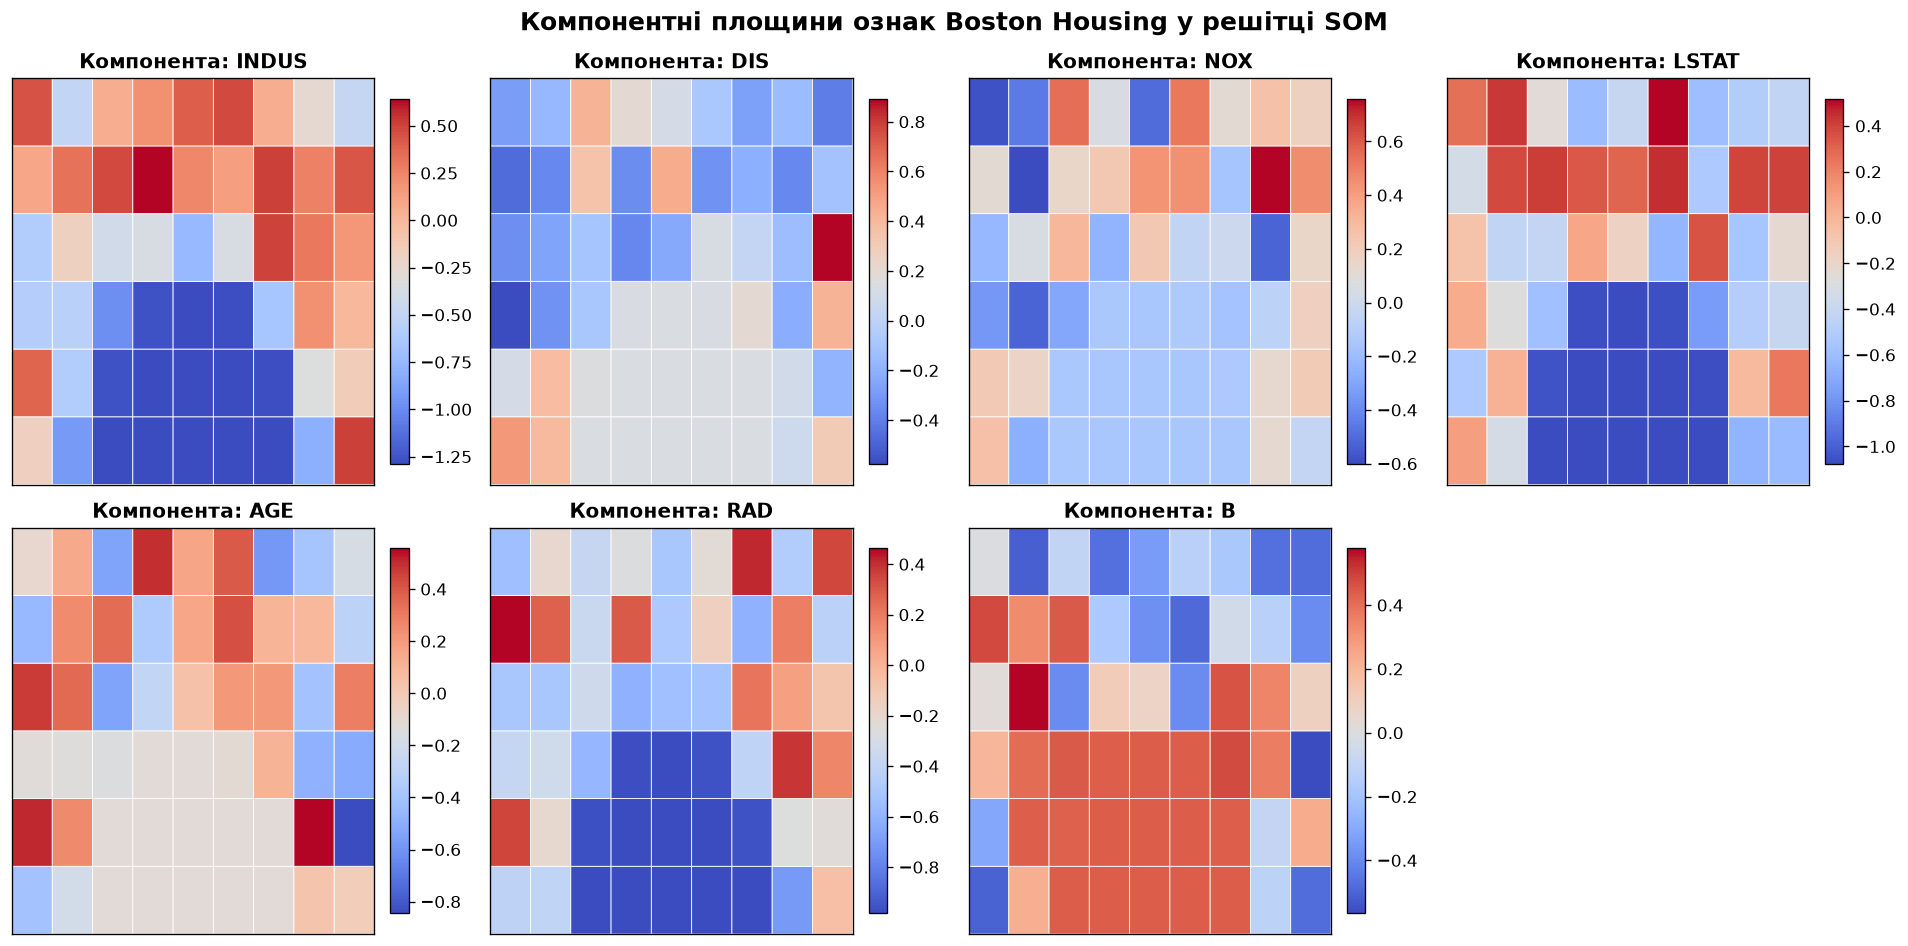

In [9]:
weights = som.get_weights()
fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=120)
axes = axes.flatten()

for idx, name in enumerate(var_names):
    ax = axes[idx]
    comp = weights[:, :, idx].T
    im = ax.pcolor(comp, cmap='coolwarm', edgecolors='white', linewidths=0.5)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Компонента: {name}", fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

fig.delaxes(axes[7])
plt.suptitle('Компонентні площини ознак Boston Housing у решітці SOM', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('figures/som_component_planes.png')
plt.show()

### Висновки
- Карта Кохонена розміром 9 x 6 успішно спроєктувала 7-вимірний простір вибірки Boston Housing на 2D-решітку зі стійким збіганням похибки квантування (фінальне значення 1.7809).
- Карта U-Matrix та матриця частоти активацій виявили стабільні топологічні кластери без надмірних порожніх зон (максимальна щільність досягає 23 спостережень на нейрон).
- Завдяки компонентним площинам встановлено сильну позитивну кореляцію між рівнем забруднення (NOX), часткою промисловості (INDUS), віком будинків (AGE) та показником бідності (LSTAT), а також їхній обернений зв'язок із відстанню до ділових центрів (DIS).